In [3]:
import pandas as pd
import numpy as np

In [9]:

# Load the data
df = pd.read_csv(r"Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [10]:
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

In [11]:
df.dtypes

CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [12]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


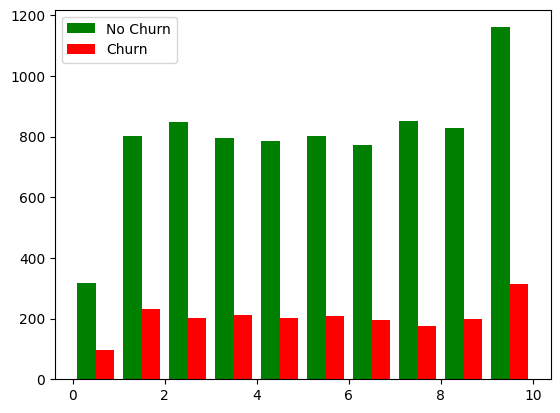

In [13]:
churn_no = df[df.Exited == 0].Tenure
churn_yes = df[df.Exited == 1].Tenure
import matplotlib.pyplot as plt
plt.hist([churn_no, churn_yes], color=['green', 'red'], label=['No Churn', 'Churn'])
plt.legend()

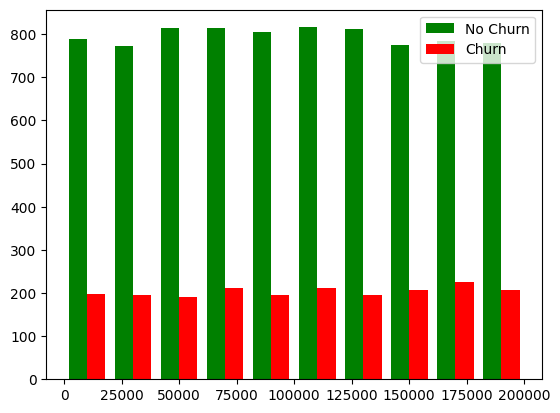

In [14]:
sal_no = df[df.Exited == 0].EstimatedSalary
sal_yes = df[df.Exited == 1].EstimatedSalary
plt.hist([sal_no, sal_yes], color=['green', 'red'], label=['No Churn', 'Churn'])
plt.legend()

In [15]:
def print_unique_col_values(df):
    for column in df:
        if df[column].dtypes == 'object':
            print(f'{column}: {df[column].unique()}')

In [16]:
print_unique_col_values(df)

Geography: ['France' 'Spain' 'Germany']
Gender: ['Female' 'Male']


In [17]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [18]:
df.replace({'Gender': {'Male': 0, 'Female': 1}}, inplace=True)

C:\Users\dilji\AppData\Local\Temp\ipykernel_8292\926105093.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'Gender': {'Male': 0, 'Female': 1}}, inplace=True)


In [19]:
print_unique_col_values(df)

Geography: ['France' 'Spain' 'Germany']


one hot encoding for geography

In [24]:
df1 = pd.get_dummies(data=df, columns=['Geography'], drop_first=True, dtype=np.int8)
df1.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,1,42,2,0.00,1,1,1,101348.88,1,0,0
1,608,1,41,1,83807.86,1,0,1,112542.58,0,0,1
2,502,1,42,8,159660.80,3,1,0,113931.57,1,0,0
3,699,1,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,1,43,2,125510.82,1,1,1,79084.10,0,0,1


In [25]:
from sklearn.preprocessing import minmax_scale
df1['CreditScore'] = minmax_scale(df1['CreditScore'])
df1['Age'] = minmax_scale(df1['Age'])
df1['Tenure'] = minmax_scale(df1['Tenure'])
df1['Balance'] = minmax_scale(df1['Balance'])
df1['NumOfProducts'] = minmax_scale(df1['NumOfProducts'])
df1['EstimatedSalary'] = minmax_scale(df1['EstimatedSalary'])
df1.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,0.538,1,0.324324,0.2,0.000000,0.000000,1,1,0.506735,1,0,0
1,0.516,1,0.310811,0.1,0.334031,0.000000,0,1,0.562709,0,0,1
2,0.304,1,0.324324,0.8,0.636357,0.666667,1,0,0.569654,1,0,0
3,0.698,1,0.283784,0.1,0.000000,0.333333,0,0,0.469120,0,0,0
4,1.000,1,0.337838,0.2,0.500246,0.000000,1,1,0.395400,0,0,1


In [26]:
for col in df1:
    print(f'{col}: {df1[col].unique()}')

CreditScore: [0.538 0.516 0.304 0.698 1.    0.59  0.944 0.052 0.302 0.668 0.356 0.294
 0.252 0.398 0.57  0.532 0.606 0.474 0.752 0.764 0.572 0.32  0.638 0.992
 0.454 0.812 0.442 0.448 0.122 0.482 0.366 0.406 0.34  0.744 0.25  0.28
 0.908 0.464 0.244 0.23  0.412 0.968 0.62  0.852 0.958 0.574 0.4   0.696
 0.47  0.876 0.61  0.502 0.612 0.75  0.322 0.528 0.784 0.674 0.41  0.506
 0.802 0.462 0.77  0.622 0.65  0.776 0.926 0.614 0.508 0.338 0.628 0.656
 0.814 0.132 0.63  0.854 0.386 0.312 0.286 0.604 0.8   0.758 0.592 0.594
 0.916 0.348 0.838 0.76  0.33  0.846 0.928 0.72  0.126 0.546 0.64  0.544
 0.87  0.51  0.258 0.67  0.376 0.424 0.742 0.556 0.636 0.956 0.648 0.55
 0.164 0.84  0.816 0.89  0.672 0.878 0.478 0.222 0.468 0.458 0.626 0.664
 0.886 0.682 0.27  0.6   0.808 0.37  0.732 0.378 0.712 0.472 0.562 0.734
 0.9   0.666 0.708 0.53  0.634 0.268 0.26  0.456 0.324 0.512 0.494 0.856
 0.328 0.35  0.73  0.46  0.914 0.342 0.818 0.332 0.722 0.536 0.586 0.642
 0.678 0.54  0.652 0.444 0.69  0.484 0.4

train test split

In [27]:
x = df1.drop(columns=['Exited'])
y = df1.Exited
x.head()
y.head()

0    1
1    0
2    1
3    0
4    0
Name: Exited, dtype: int64

In [28]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [29]:
x_train.shape

(8000, 11)

In [30]:
y_test.shape

(2000,)

In [32]:
len(x_train.columns)

11

build a model ANN

In [34]:
import tensorflow as tf
from tensorflow import keras

model = keras.Sequential([
    keras.layers.Dense(20, input_shape=(11,), activation='relu'),
    keras.layers.Dense(15, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam', 
    loss='binary_crossentropy', 
    metrics=['accuracy'])

model.fit(x_train, y_train, epochs=100)

Epoch 1/100


c:\Users\dilji\Documents\AI-Engineer\venv\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 892us/step - accuracy: 0.7261 - loss: 0.5655
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 874us/step - accuracy: 0.7952 - loss: 0.4724
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 841us/step - accuracy: 0.8024 - loss: 0.4554
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 841us/step - accuracy: 0.8081 - loss: 0.4441
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 835us/step - accuracy: 0.8116 - loss: 0.4318
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 846us/step - accuracy: 0.8161 - loss: 0.4196
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 845us/step - accuracy: 0.8257 - loss: 0.4036
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 844us/step - accuracy: 0.8345 - loss: 0.3885
Epoch 9/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 850us/step - accuracy: 0.8379 - loss: 0.3771
Epoch 10/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 879us/step - accuracy: 0.8438 - loss: 0.3701
Epoch 11/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 847us/step - accuracy: 0.8449 - loss: 0.3657
Epoch 12/100
250/250 ━━━━━━━━━━

model evaluation

In [35]:
model.evaluate(x_test, y_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8620 - loss: 0.3360  


[0.3359503149986267, 0.8619999885559082]

In [36]:
yp = model.predict(x_test)
yp[:5]

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


array([[0.04615755],
       [0.01785128],
       [0.11114903],
       [0.10211671],
       [0.03504077]], dtype=float32)

In [37]:
y_pred = []
for element in yp:
    if element > 0.5:
        y_pred.append(1)
    else:
        y_pred.append(0)

In [40]:
y_pred[:12]

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1]

In [41]:
y_test[:12]

6252    0
4684    0
1731    0
4742    0
4521    0
6340    0
576     0
5202    1
6363    0
439     0
2750    1
7487    1
Name: Exited, dtype: int64

classification report and confution matrix

In [42]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.74      0.46      0.57       393

    accuracy                           0.86      2000
   macro avg       0.81      0.71      0.74      2000
weighted avg       0.85      0.86      0.85      2000

[[1543   64]
 [ 212  181]]


Text(95.72222222222221, 0.5, 'Truth')

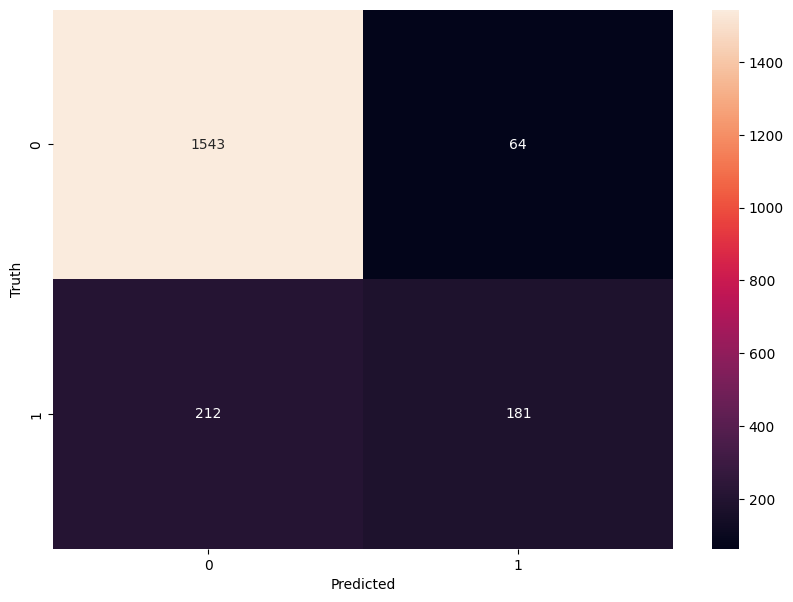

In [44]:
import seaborn as sns
cm = tf.math.confusion_matrix(labels=y_test, predictions=y_pred)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [45]:
y_test.shape

(2000,)

Accuracy

In [47]:
round((1543+181)/(1543+181+212+64), 2)

0.86

precision for 0 class (not exit)

In [57]:
p0 = round(1543/(1543+212), 2)
p0

0.88

precision for 1 class (exit)

In [58]:
p1 = round(181/(181+64),2)
p1

0.74

recall for  0 class

In [59]:
r0 = round(1543/(1543+64),2)
r0

0.96

recall for 1 class

In [60]:
r1 = round(181/(181+212),2)
r1

0.46

F1 score for 0 (F1 Score = 2 * (Precision * Recall) / (Precision + Recall))

In [61]:
f1_0 = round(2 * (p0 * r0) / (p0 + r0), 2)
f1_0 

0.92

F1 score for 1 (F1 Score = 2 * (Precision * Recall) / (Precision + Recall))

In [62]:
f1_1 = round(2 * (p1 * r1) / (p1 + r1), 2)
f1_1

0.57

completed